In [1]:
run_batchprocess = False

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os,glob
import re
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess/code/')
from pprint import pprint 
from prepare_img_utils import *
from utils import get_paths

import scanpy as sc
import anndata as ad
import scvi
from registerCCF_util import *

def get_record(s):
    return {
        'filename':s.get('filename'),
        'height': s.get('height'),
        'width': s.get('width'), 
        'ox': s.get('anchoring')[0], 
        'oy': s.get('anchoring')[1],
        'oz': s.get('anchoring')[2],
        'ux': s.get('anchoring')[3],
        'uy': s.get('anchoring')[4],
        'uz': s.get('anchoring')[5], 
        'vx': s.get('anchoring')[6], 
        'vy': s.get('anchoring')[7],
        'vz': s.get('anchoring')[8],
    }

HOMEDIR = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/'
paths = get_paths()
print(paths.keys())

dict_keys(['package_root', 'data_root', 'merfish_metadata', 'registered_output'])


In [35]:
# manually change those
paths['data_root'] = '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/'
paths['registered_output'] = '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing'

In [21]:
paths['registered_output']

PosixPath('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess/scratch/merfish_results/registered')

In [12]:
scaling_factor=1/32; 
# all_file_path = paths['data_root'] /'image_xml/*.jpg'
all_file_path = os.path.join(paths['data_root'], 'image_xml', '*.jpg')
for f in glob.glob(all_file_path):
    print(os.path.basename(f).split('cell_img_')[1].split('.')[0])   # btw these images are 25um resolutions

MouseC_C2
MouseC_C3
MouseC_C4
MouseC_C5
MouseEg_B3
MouseEg_Eg1
MouseEg_Eg2
MouseEg_Eg3
MouseEg_Eg4
MouseEg_Eg5
MouseF_F1
MouseF_F2
MouseF_F3
MouseF_F4
MouseZM_ZM0
MouseZM_ZM1
MouseZM_ZM2
MouseZM_ZM3
MouseZM_ZM4
MouseZM_ZM5p1
MouseZM_ZM5p2
MouseZM_ZM6p1
MouseZM_ZM7p1
MouseZM_ZM7p2


In [13]:
slicename_all = [os.path.basename(f).split('cell_img_')[1].split('.')[0] for f in glob.glob(all_file_path)]
slicename_all.sort()
print(slicename_all, len(slicename_all))

['MouseC_C2', 'MouseC_C3', 'MouseC_C4', 'MouseC_C5', 'MouseEg_B3', 'MouseEg_Eg1', 'MouseEg_Eg2', 'MouseEg_Eg3', 'MouseEg_Eg4', 'MouseEg_Eg5', 'MouseF_F1', 'MouseF_F2', 'MouseF_F3', 'MouseF_F4', 'MouseZM_ZM0', 'MouseZM_ZM1', 'MouseZM_ZM2', 'MouseZM_ZM3', 'MouseZM_ZM4', 'MouseZM_ZM5p1', 'MouseZM_ZM5p2', 'MouseZM_ZM6p1', 'MouseZM_ZM7p1', 'MouseZM_ZM7p2'] 24


In [14]:
len(slicename_all)

24

# batch process

In [15]:
paths

{'package_root': PosixPath('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess'),
 'data_root': '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/',
 'merfish_metadata': PosixPath('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess/data/merfish/metadata'),
 'registered_output': PosixPath('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess/scratch/merfish_results/registered')}

In [17]:
HOMEDIR = str(paths['data_root'])

In [18]:
HOMEDIR

'/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/'

In [19]:
from PIL import Image
if run_batchprocess:
    save_flag = True
    plotting_2d = False
    plotting_3d = False
    slicenum = ['1']
    slicenum=[int(i) for i in slicenum]

    registered_output = paths['registered_output']
    os.makedirs(registered_output, exist_ok=True)

    for name_of_slice in slicename_all:
        image_files=glob.glob(HOMEDIR + f'/image_xml/*{name_of_slice}.jpg')
        # load your file
        flat_name=[]  
        for i in image_files:
            result=re.search('(.*).jpg', i)
            n=result.group(1)+('_nl.flat')
            flat_name+=[n]
        assert(len(image_files)==1)
        with Image.open(image_files[0]) as im:
            w, h = im.size
        json_name=image_files 
        d = {'slicenum': slicenum, 'json_name': json_name,'flat_name':flat_name}
        name_df=pd.DataFrame(data=d)
        neurons=pd.read_csv(HOMEDIR+f'/filt_neurons_all/filt_neurons_{name_of_slice}.csv')
        neurons=neurons[neurons['slice'].isin(slicenum)]
        Max=neurons['x'].max()
        Min=neurons['y'].max()
        neurons['rescale_x']=neurons['x']*scaling_factor
        neurons['rescale_y']=neurons['y']*scaling_factor
        neurons['rescale_x'] = neurons['rescale_x'].astype(float)+500 # this was accounting for the padding that we created for the image
        neurons['rescale_y'] = neurons['rescale_y'].astype(float)+500

        # load visualign results 
        with open(HOMEDIR+f'/visualign_rez/{name_of_slice}.json') as f:
            vafile=json.load(f)
        details={s.get('filename'):s for s in vafile['slices']}
        assert(name_of_slice in list(details.keys())[0])

        rez = neurons.groupby('slice', group_keys=False).apply(lambda g: get_adjusted_points(g.assign(slice=g.name), name_df,details)).reset_index(drop=True)
        neurons[['adjusted_x', 'adjusted_y']]= rez
        neurons_nl=neurons.copy()
        neurons_nl['clustid'] =neurons_nl['clustid'].astype(str)

        # load quickniii results 
        f = open(HOMEDIR+f'/quicknii_rez/quicknii_{name_of_slice}.json','r')
        data=json.loads(f.read())
        anchor=pd.DataFrame.from_records([get_record(s) for s in data['slices']])
        f.close()

        vox_dfs = []
        for slice_num, df in neurons_nl.groupby('slice'):
            quicknii_cord = get_quicknii_cord(slice_num, df,name_df,anchor,h,w) # Height and Width of image file
            vox_cord = get_vox_cord(quicknii_cord)
            vox_dfs += [vox_cord]    
        vox_df = pd.concat(vox_dfs)
        if save_flag:
            vox_df.to_csv(os.path.join(registered_output, f'registered_{name_of_slice}.csv'), index=False)
else:
    print('skip the batch process!')

skip the batch process!


#  now pull all these together 

In [36]:
reg_file_path = str(paths['registered_output']) + '/registered/'
pprint(glob.glob(reg_file_path+'*'))

['/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C2.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C3.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C4.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseC_C5.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_B3.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_Eg1.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_Eg2.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/registered_MouseEg_Eg3.csv',
 '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/registered/reg

In [37]:
paths

{'package_root': PosixPath('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess'),
 'data_root': '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/',
 'merfish_metadata': PosixPath('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess/data/merfish/metadata'),
 'registered_output': '/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing'}

In [38]:
slicename_all

['MouseC_C2',
 'MouseC_C3',
 'MouseC_C4',
 'MouseC_C5',
 'MouseEg_B3',
 'MouseEg_Eg1',
 'MouseEg_Eg2',
 'MouseEg_Eg3',
 'MouseEg_Eg4',
 'MouseEg_Eg5',
 'MouseF_F1',
 'MouseF_F2',
 'MouseF_F3',
 'MouseF_F4',
 'MouseZM_ZM0',
 'MouseZM_ZM1',
 'MouseZM_ZM2',
 'MouseZM_ZM3',
 'MouseZM_ZM4',
 'MouseZM_ZM5p1',
 'MouseZM_ZM5p2',
 'MouseZM_ZM6p1',
 'MouseZM_ZM7p1',
 'MouseZM_ZM7p2']

# load all the coords + genes

In [44]:

genecounts_all = dict()
reg_points_all = dict()
for name in slicename_all:  
    
    reg_points_path = reg_file_path + f'registered_{name}.csv'
    df = pd.read_csv(reg_points_path, on_bad_lines='skip')[['neuron_id','x_CCF','y_CCF','z_CCF']]    
    reg_points_all[name] = df
    
    thisdircheck =  '/home/shuonan.chen/scratch_shuonan/pons_images/' + name + '/' + 'analyzed_data/*/region_*/'
    alltifregions = np.array([[s for s in m.split('/') if 'region' in s][0] for m in glob.glob(thisdircheck + '/images/*.tif')])
    values, counts = np.unique(alltifregions, return_counts=True)
    region_chosen = values[np.argmax(counts)]
    thisdircheck = '/home/shuonan.chen/scratch_shuonan/pons_images/'+ name + '/' + f'analyzed_data/*/{region_chosen}/'

    cell_loc_path = glob.glob(thisdircheck + 'cell_metadata.csv')[0]
    countmatrix_path = glob.glob(thisdircheck+'cell_by_gene.csv')[0]
    count_mtx = pd.read_csv(countmatrix_path, index_col=0).sort_index()
    genecounts_all[name] = count_mtx

In [45]:
np.unique(alltifregions, return_counts=True)

(array(['region_0'], dtype='<U8'), array([14]))

In [46]:
thisdircheck

'/home/shuonan.chen/scratch_shuonan/pons_images/MouseZM_ZM7p2/analyzed_data/*/region_0/'

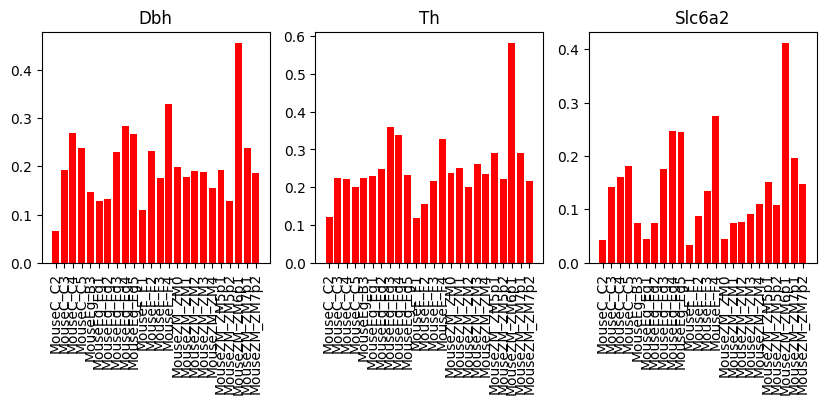

In [47]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
plt.figure(figsize = (10, 3))
for k,g in enumerate(markergenes):
    plt.subplot(1,3,k+1)
    for k, v in genecounts_all.items():
        expr = np.array(v[g]).flatten()
        plt.bar(k,np.mean(expr), color = 'red')
    plt.xticks(rotation=90);
    plt.title(g)
    


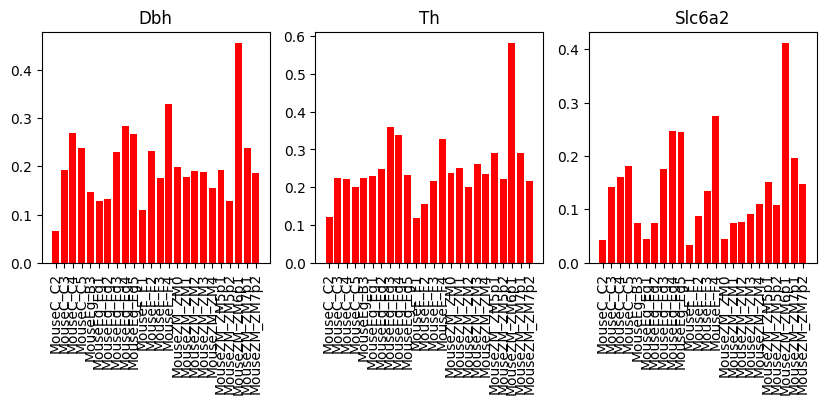

In [48]:
markergenes = ['Dbh', 'Th', 'Slc6a2']
plt.figure(figsize = (10, 3))
for k,g in enumerate(markergenes):
    plt.subplot(1,3,k+1)
    for k, v in genecounts_all.items():
        expr = np.array(v[g]).flatten()
        plt.bar(k,np.mean(expr), color = 'red')
    plt.xticks(rotation=90);
    plt.title(g)
    


In [49]:
out_df_gene = []
out_df_loc = []
for p,name in enumerate(slicename_all):
    totalexpression = np.prod(np.array([genecounts_all[name][k].values for k in markergenes]), 0)
     # Boolean to indicaet if all three marker genes have to be expressed  in this cell!
    keptcellID = totalexpression>10   # if this is zero, we will have 7k cells. if this is 10 then we will have 5.4k cells
    
    # for gene counts
    foo_df = genecounts_all[name].iloc[keptcellID] 
    foo_df= foo_df.assign(slicename=list(np.repeat(name,(keptcellID).sum())))
    out_df_gene.append(foo_df)
    
    # for locations
    foo_df = reg_points_all[name].iloc[keptcellID]
    foo_df.index = foo_df['neuron_id']
    out_df_loc.append(foo_df)
    
out_df_gene = pd.concat(out_df_gene)    
out_df_loc = pd.concat(out_df_loc)    
out_df_gene.index.name = 'neuron_id'

In [50]:
df = pd.concat((out_df_loc,out_df_gene),axis=1)

In [51]:
df.shape

(5473, 390)

In [52]:
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]

df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")


In [53]:

allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    

In [54]:
dictkeys = list(['MouseC', 'MouseEg', 'MouseF', 'MouseZM'])
dictvals = list(['M', 'F', 'F', 'M'])
mouse_sex_map = {key: value for key, value in zip(dictkeys, dictvals)}

adata_mer.obsm["spatial"] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.raw = adata_mer.copy()
adata_mer.obs['mouse_name'] = section_identifier_highlevel
adata_mer.obs["slicename"] = adata_mer.obs["slicename"].astype("category")
adata_mer.obs['mouse_sex'] = adata_mer.obs['mouse_name'].map(mouse_sex_map)

In [55]:
markergenesid = np.array([np.where(adata_mer.var_names==m)[0][0] for m in markergenes])
totalexpression = np.prod(adata_mer.X[:,markergenesid], 1)


# Boolean to indicaet if all three marker genes have to be expre
keptcellID = totalexpression>0
adata_mer = adata_mer[keptcellID]

In [56]:
totalexpression.shape

(5473,)

In [57]:
adata_mer.shape

(5473, 315)

# potential doubletes removal 

# scvi

In [58]:
adata_mer.obs

,slicename,x_CCF,y_CCF,z_CCF,mouse_name,mouse_sex
neuron_id,,,,,,
103685216640203968188516774531086347883,MouseC_C2,409.606844,236.687088,179.309040,MouseC,M
104587908325765086675948399347513609206,MouseC_C2,407.892948,204.334839,265.870224,MouseC,M
107556232960175669029944473037950900912,MouseC_C2,409.104832,227.210884,174.501084,MouseC,M
110143770882700220040132120043038831763,MouseC_C2,407.519014,197.276290,266.738031,MouseC,M
113385467015087615676147138608792183276,MouseC_C2,410.125922,246.485426,165.601449,MouseC,M
...,...,...,...,...,...,...
9623349862178950852359237543126573460,MouseZM_ZM7p2,424.358181,171.836997,192.938647,MouseZM,M
96245750577479322584616409396904825217,MouseZM_ZM7p2,424.299410,171.174947,194.574443,MouseZM,M
9744450250461526053237534442143333842,MouseZM_ZM7p2,423.905352,178.786117,191.780986,MouseZM,M


In [59]:
scvi.settings.seed = 1
umap_random_state = 307
adata_mer = adata_mer.copy()
scvi.model.SCVI.setup_anndata(adata_mer, batch_key="slicename")
model = scvi.model.SCVI(adata_mer, n_layers=1, n_latent=4)
model.train()


INFO: [rank: 0] Seed set to 1
INFO:lightning.fabric.utilities.seed:[rank: 0] Seed set to 1
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /allen/aind/scratch/shuonan.chen/conda_envs/torch_on ...
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `s

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.


In [60]:
adata_mer.obsm["X_scVI"] = model.get_latent_representation()
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state, n_neighbors=30)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=1,  random_state=umap_random_state)


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)
/scratch/fast/15591074/ipykernel_3604111/3228789248.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_mer, resolution=1,  random_state=umap_random_state)


... storing 'mouse_name' as categorical
... storing 'mouse_sex' as categorical


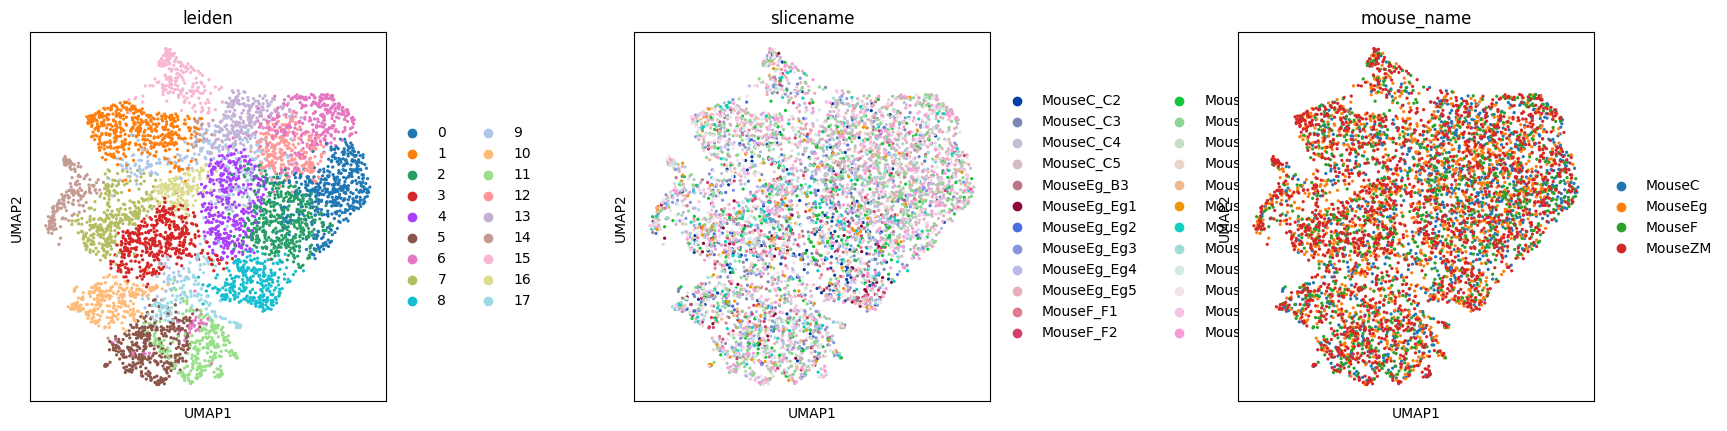

In [61]:
ax = sc.pl.umap(
    adata_mer,
    color=["leiden",'slicename','mouse_name'],show = False,
    ncols=3,
)
for a in ax:
    a.set_aspect('equal')

In [62]:
all_batches = model.adata_manager.get_state_registry("batch").categorical_mapping.tolist()
print(all_batches)

[np.str_('MouseC_C2'), np.str_('MouseC_C3'), np.str_('MouseC_C4'), np.str_('MouseC_C5'), np.str_('MouseEg_B3'), np.str_('MouseEg_Eg1'), np.str_('MouseEg_Eg2'), np.str_('MouseEg_Eg3'), np.str_('MouseEg_Eg4'), np.str_('MouseEg_Eg5'), np.str_('MouseF_F1'), np.str_('MouseF_F2'), np.str_('MouseF_F3'), np.str_('MouseF_F4'), np.str_('MouseZM_ZM0'), np.str_('MouseZM_ZM1'), np.str_('MouseZM_ZM2'), np.str_('MouseZM_ZM3'), np.str_('MouseZM_ZM4'), np.str_('MouseZM_ZM5p1'), np.str_('MouseZM_ZM5p2'), np.str_('MouseZM_ZM6p1'), np.str_('MouseZM_ZM7p1'), np.str_('MouseZM_ZM7p2')]


# get batch corrected reults

In [63]:
X_hat_avg =model.get_normalized_expression(adata_mer, 
                                           return_numpy=False,
                                          transform_batch=all_batches,    
                                           library_size= 1)  

adata_BN = anndata.AnnData(X_hat_avg.copy())
adata_BN.obs = adata_mer.obs.copy()
adata_BN.obsm = adata_mer.obsm.copy()
adata_BN.var = adata_mer.var.copy()

cpm_scl= 1
adata_mer.layers["BN"] = X_hat_avg*cpm_scl

NameError: name 'anndata' is not defined

In [ ]:
# mesh = trimesh.load_mesh("/home/shuonan.chen/scripts/Pons_MERFISH/mesh/Segmentation_sm_6pix_dil_both_sides_aligned_with_ccf_index 1.obj")
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

# here we must choose our clusters

In [ ]:
axes = sc.pl.umap(adata_mer, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')
    
axes = sc.pl.umap(adata_BN, color=['Dbh','Slc6a2','Th','leiden'],
           cmap ='Reds',ncols=2,palette="tab20",show = False,
           alpha =.9) 
for a in axes:
    a.set_aspect('equal')    

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

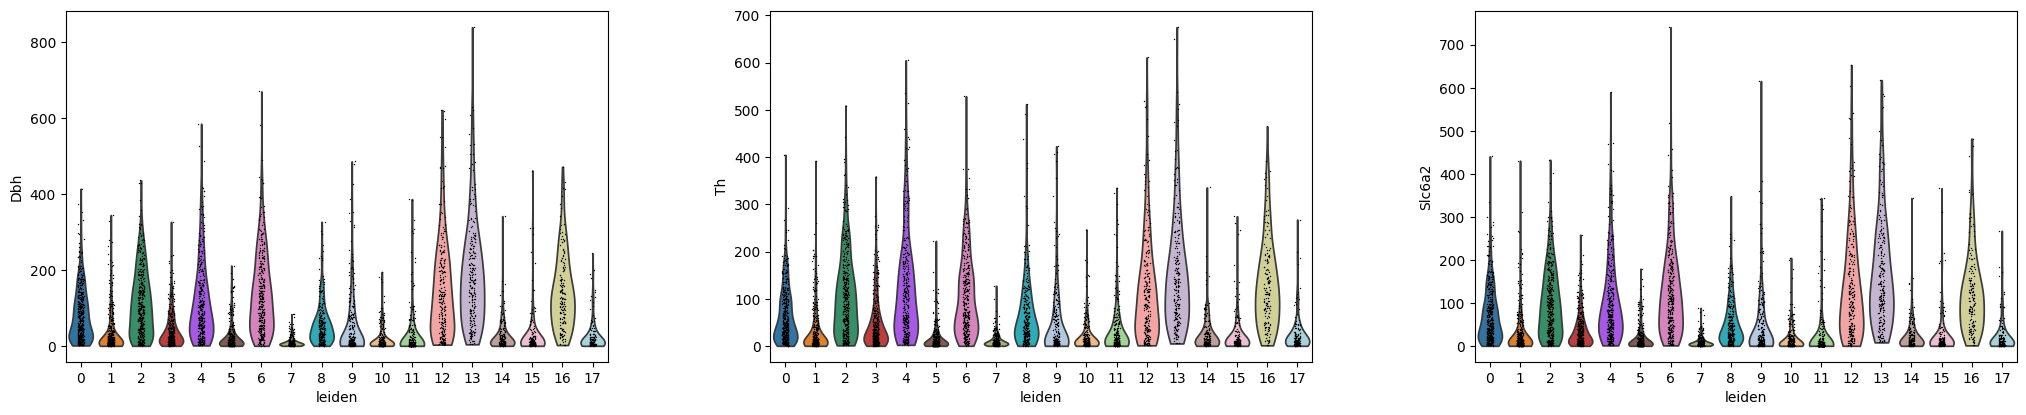

In [64]:
intersted_genes =['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']
# Check expression of known markers
sc.pl.violin(adata_mer, ['Dbh','Th','Slc6a2'], groupby='leiden')

In [65]:
libsize = np.sum(adata_mer.X)
expr = pd.DataFrame(
    1000*adata_mer[:, markergenes].X/libsize,
    columns=markergenes,
    index=adata_mer.obs_names
)
expr['leiden'] = adata_mer.obs['leiden'].values
cluster_means = expr.groupby('leiden')[markergenes].mean()
cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()
cluster_z

/scratch/fast/15591074/ipykernel_3604111/1932138714.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = expr.groupby('leiden')[markergenes].mean()


,Dbh,Th,Slc6a2
leiden,,,
0,0.208954,0.010032,0.199490
1,-0.680910,-0.736744,-0.674345
2,0.763513,0.941206,0.731243
3,-0.529368,-0.349371,-0.538913
4,0.777673,1.224793,0.814208
5,-0.847194,-1.044276,-0.895292
6,1.234141,0.884427,1.214462
7,-1.088757,-1.125187,-1.052706
8,-0.240325,0.104855,-0.181550


In [66]:
chosen_ks = cluster_z[
    (cluster_z['Dbh'] > 0) &
    (cluster_z['Th'] > 0) &
    (cluster_z['Slc6a2'] > 0)
].index.astype(int).tolist()
chosen_ks.sort()

# ### if we want to remove the cluster 0 
# threshold = 0  # or 0.5
# chosen_ks = cluster_z[
#     (cluster_z > threshold).all(axis=1)
# ].index.astype(int).tolist()

print("Selected clusters:", chosen_ks)

Selected clusters: [0, 2, 4, 6, 12, 13, 16]


In [67]:
# notchosen_ks=[2,12,13,6,10,4,7,8]
# chosen_ks = [
#     k for k in adata_mer.obs["leiden"].astype(int).unique()
#     if k not in notchosen_ks
# ]
# chosen_ks = [0,13,12,16,2,4,6]


mask = adata_mer.obs['leiden'].isin([str(k) for k in chosen_ks]) 
# non_mask = adata_mer.obs['leiden'].isin([str(k) for k in notchosen_ks]) 
adata_subset = adata_mer[mask].copy() 
print(f"Original size: {adata_mer.n_obs} cells")
print(f"Subset size: {adata_subset.n_obs} cells")
leidenmaskthingy = np.array(adata_subset.obs['leiden'].copy())

Original size: 5473 cells
Subset size: 2262 cells


# checking plots!

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

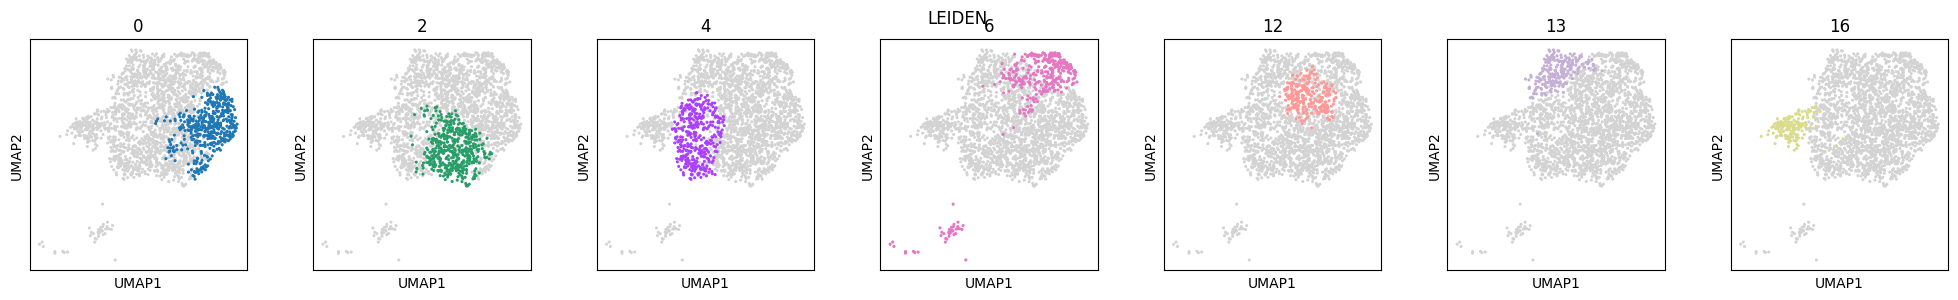

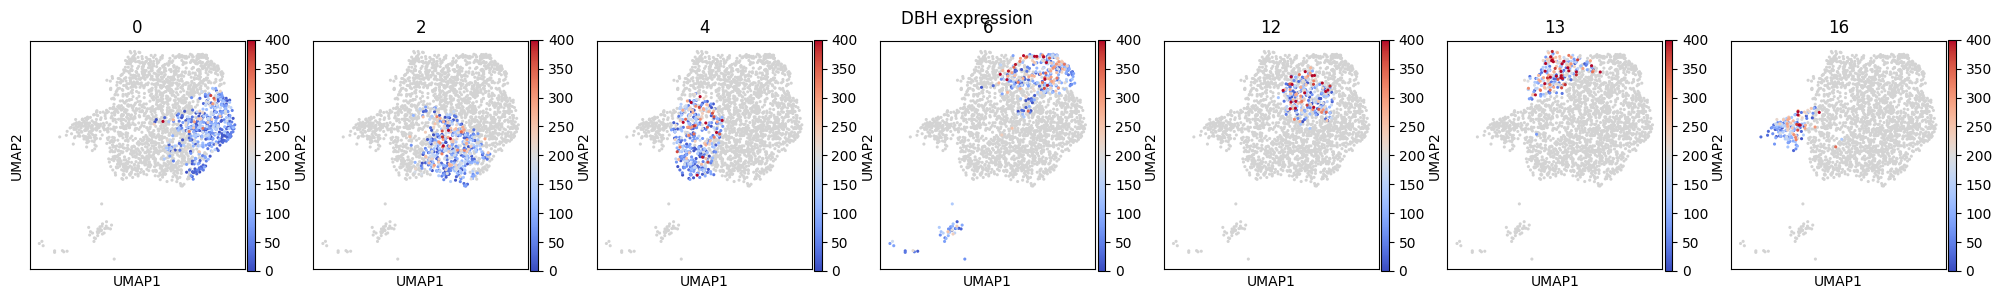

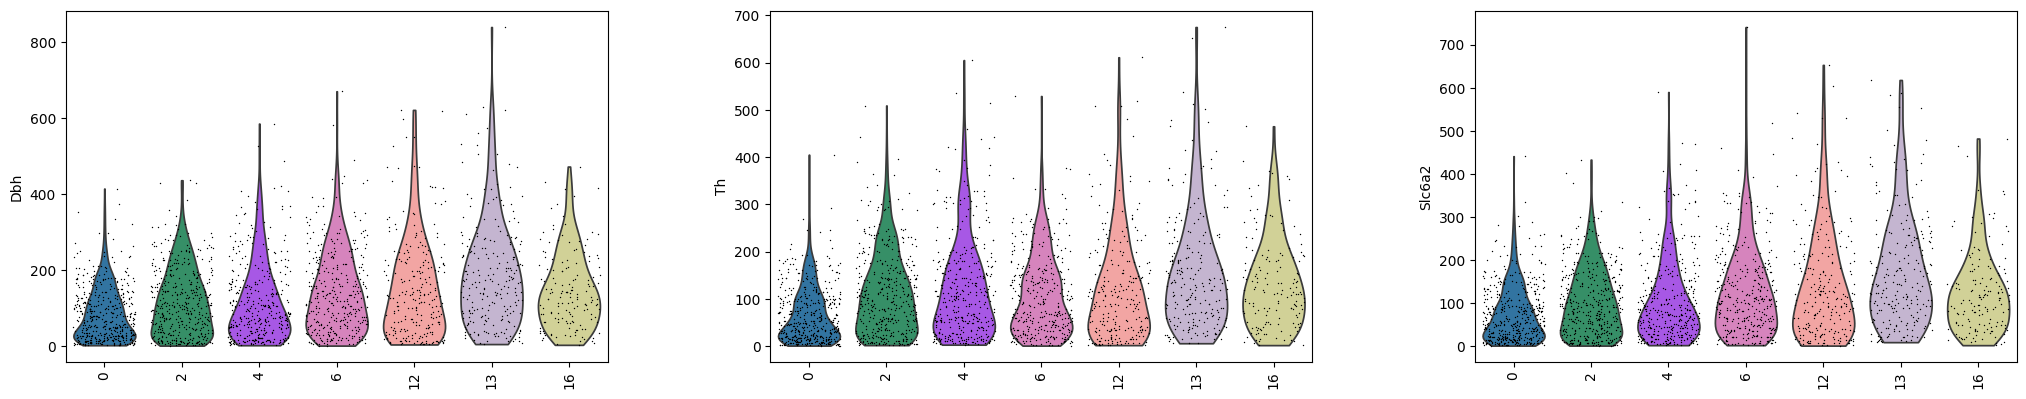

In [68]:

fig, axes = plt.subplots(1,len(chosen_ks),figsize=(25,3),)
for i,k in enumerate(chosen_ks):
    adata_subset = adata_mer[mask].copy() 
    sc.pl.umap(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',
               ax = axes[i],size = 20,alpha = 1,title=str(k), show=False, legend_loc=None,)
    axes[i].set_aspect('equal')
fig.suptitle('LEIDEN')   

fig, axes = plt.subplots(1,len(chosen_ks),figsize=(25,3),)
for i,k in enumerate(chosen_ks):
    adata_subset = adata_mer[mask].copy() 
    sc.pl.umap(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='Dbh',cmap = 'coolwarm',
               vmax = 400,vmin = 0,
               ax = axes[i],size = 20,alpha = 1,title=str(k), show=False, legend_loc=None,)
    axes[i].set_aspect('equal')
fig.suptitle('DBH expression')        
        

sc.pl.violin(
    adata_subset,
    keys=markergenes, groupby="leiden",use_raw=True,
    jitter=0.4,rotation=90, multi_panel=True)        

NameError: name 'mesh_LC' is not defined

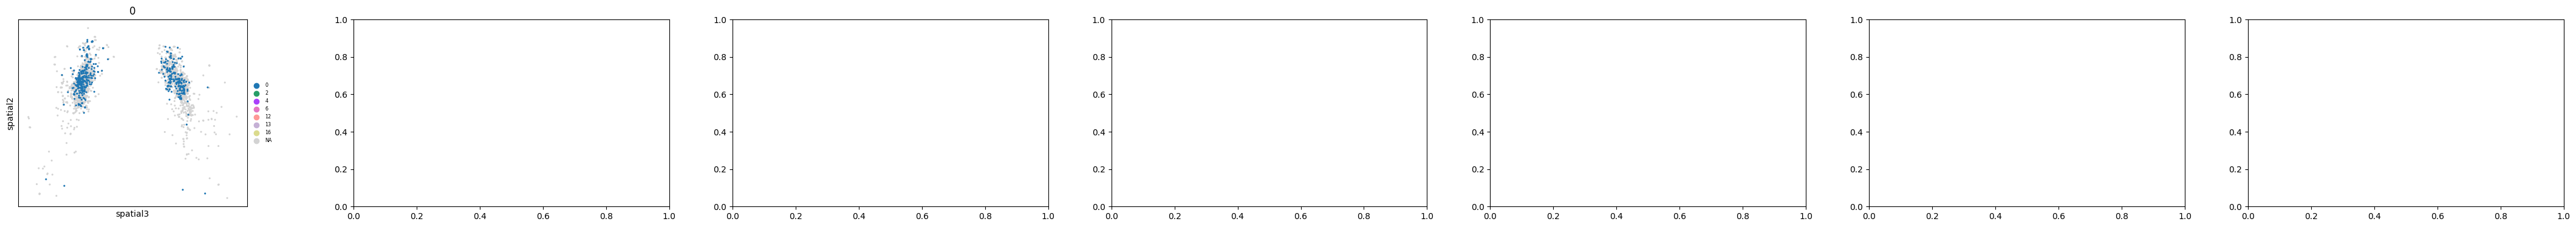

In [69]:
fig, axes = plt.subplots(1,len(chosen_ks),figsize=(55,4))

for i,k in enumerate(chosen_ks):    
    adata_subset = adata_mer[mask].copy() 
    sc.pl.embedding(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',ax = axes[i],
                     dimensions = (2, 1),basis="spatial", size = 20,alpha = 1,
                     title=str(k), show=False, legend_fontsize='xx-small',)
    axes[i].invert_yaxis()
    axes[i].set_aspect('equal')
    
    axes[i].triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    axes[i].triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    axes[i].triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    axes[i].set_ylabel('D-V')
    axes[i].set_xlabel('')

# fig.savefig('./coronal.png', dpi=200)

In [ ]:
fig, axes = plt.subplots(1,len(chosen_ks),figsize=(14,4))

for i,k in enumerate(chosen_ks):    
    adata_subset = adata_mer[mask].copy() 
    sc.pl.embedding(adata_subset,  mask_obs=(leidenmaskthingy==str(k)),color='leiden',ax = axes[i],
                     dimensions = (0, 1),basis="spatial", size = 20,alpha = 1,
                     title=str(k), show=False, legend_fontsize='xx-small',)
    axes[i].invert_yaxis()
    axes[i].set_aspect('equal')
    
    axes[i].triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    axes[i].triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    axes[i].triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    axes[i].set_ylabel('D-V')
    axes[i].set_xlabel('')

# fig.savefig('./coronal.png', dpi=200)

In [ ]:
adata_subset.obs['sex'] = adata_subset.obs['mouse_sex']

In [ ]:
adata_subset.shape

In [ ]:
np.sum(adata_mer.layers['BN'], 1)

In [70]:
adata_subset.shape

(2262, 315)

# save teh results

In [71]:
adata_subset

AnnData object with n_obs × n_vars = 2262 × 315
    obs: 'slicename', 'x_CCF', 'y_CCF', 'z_CCF', 'mouse_name', 'mouse_sex', '_scvi_batch', '_scvi_labels', 'leiden'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'slicename_colors', 'mouse_name_colors'
    obsm: 'spatial', 'X_scVI', 'X_umap'
    obsp: 'distances', 'connectivities'

In [74]:
adata_subset.shape

(2262, 315)

In [75]:
adata_subset = adata_mer[mask].copy() 
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_2k.h5ad'
adata_subset.write(filename)


In [79]:
selected_cells_path = '/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess/data/merfish/selected_cell_ids.json'
selected_cells = adata_mer.obs_names[mask].tolist()
with open(selected_cells_path, 'w') as f:
    json.dump(selected_cells, f)
print(f"Saved {len(selected_cells)} cell IDs to {selected_cells_path}")

Saved 2262 cell IDs to /home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics_preprocess/data/merfish/selected_cell_ids.json
